In [1]:
!pip install scipy

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import arcgis
import getpass
from arcgis.mapping import WebMap
import zipfile

/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


      OBJECTID  BLKGRP BLOCK                GEOID_left  Bl_totalpo   TRACT  \
0            1       1  1004  7500000US110010001021004    0.019941  000102   
1            2       1  1006  7500000US110010001021006    0.086303  000102   
2            3       1  1001  7500000US110010001021001    0.019941  000102   
3            4       3  3009  7500000US110010014023009    0.052958  001402   
4            5       1  1009  7500000US110010024001009    0.019287  002400   
...        ...     ...   ...                       ...         ...     ...   
6007      6008       1  1000  7500000US110010075031000    0.018960  007503   
6008      6009       2  2008  7500000US110010075032008    0.143184  007503   
6009      6010       5  5021  7500000US110010076015021    0.020268  007601   
6010      6011       1  1017  7500000US110010075031017    0.022556  007503   
6011      6012       1  1011  7500000US110010095041011    0.019941  009504   

              GEOCODE  STATE  Longitude   Latitude  Total Popu 

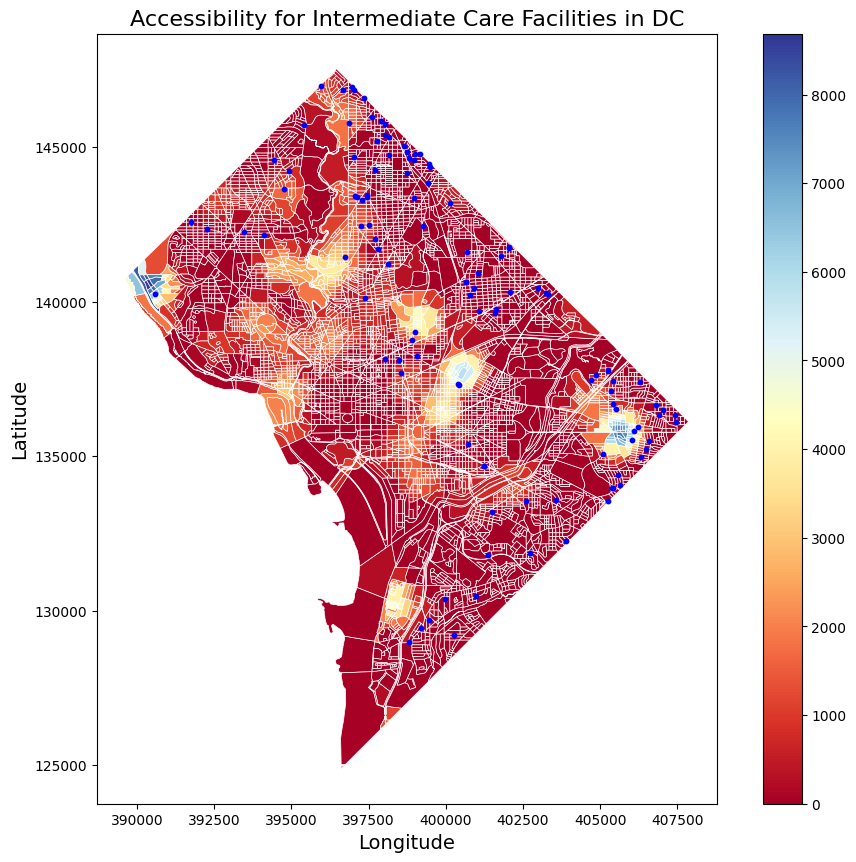

In [2]:


# Load DC ICF data
schools = gpd.read_file('/Users/ushashi/Documents/codes/Intermediate_Care_Facilities.shp').to_crs('epsg:26985')
pd.set_option('display.max_columns', None)

# Load population data
populations = gpd.read_file('/Users/ushashi/Documents/codes/blocksandtract_economic_final.shp').to_crs('epsg:26985')
populations

populations['Bl_totalpo']= populations['Bl_totalpo'].fillna(0)
populations['PerCapitaI']= populations['PerCapitaI'].fillna(0)
populations['HI_block']= populations['HI_block'].fillna(0)
populations['age_18to65'] = populations['age_18to65'].fillna(0)

# Normalize the additional variables
populations['Bl_totalpo'] = (populations['Bl_totalpo'] - populations['Bl_totalpo'].min()) / (populations['Bl_totalpo'].max() - populations['Bl_totalpo'].min())
populations['PerCapitaI'] = (populations['PerCapitaI'] - populations['PerCapitaI'].min()) /(populations['PerCapitaI'].max() - populations['PerCapitaI'].min())
populations['HI_block'] = (populations['HI_block'] - populations['HI_block'].min()) / (populations['HI_block'].max() - populations['HI_block'].min())
populations['age_18to65'] = (populations['age_18to65'] - populations['age_18to65'].min()) /(populations['age_18to65'].max() - populations['age_18to65'].min())

print(populations)
# Set constant scaling factor J
J = 1

# Set distance decay parameter for time
d0_time = 900  # 15 minutes in seconds

# Define distance decay function for time
def time_decay(distance, d0=d0_time):
    return (np.exp(-0.5 * (distance / d0) ** 2) - np.exp(-0.5)) / (1 - np.exp(-0.5))

# Precompute centroid coordinates
schools_coords = np.array(list(schools.geometry.centroid.apply(lambda geom: (geom.x, geom.y))))
populations_coords = np.array(list(populations.geometry.centroid.apply(lambda geom: (geom.x, geom.y))))

# Create spatial index for populations
pop_tree = cKDTree(populations_coords)

# Calculate weights for each school
weights = np.zeros(len(schools))

# Efficiently calculate distances and weights
for idx, school in schools.iterrows():
    school_coords = np.array([school.geometry.centroid.x, school.geometry.centroid.y])
    distances, indices = pop_tree.query(school_coords, k=len(populations), distance_upper_bound=d0_time)
    
    valid_indices = indices[distances <= d0_time]
    valid_distances = distances[distances <= d0_time]
    
    for i, distance in zip(valid_indices, valid_distances):
        if i < len(populations) and distance <= d0_time:
            weight_factor = (
                populations.at[i, 'Total Popu'] + 
                populations.at[i, 'PerCapitaI'] +
                populations.at[i, 'HI_block'] +
                populations.at[i, 'age_18to65']
            )
            weights[idx] += weight_factor * time_decay(distance)

# Calculate accessibility for each census tract and school
accessibility = np.zeros((len(populations), len(schools)))

# Efficiently calculate distances and demands
for school_idx, school in schools.iterrows():
    demand = np.zeros(len(populations))
    school_coords = np.array([school.geometry.centroid.x, school.geometry.centroid.y])
    distances, indices = pop_tree.query(school_coords, k=len(populations), distance_upper_bound=d0_time)
    
    valid_indices = indices[distances <= d0_time]
    valid_distances = distances[distances <= d0_time]
    
    for i, distance in zip(valid_indices, valid_distances):
        if i < len(populations) and distance <= d0_time:
            demand[i] = populations.at[i, 'Total Popu'] * time_decay(distance)
    
    for origin_idx, origin in populations.iterrows():
        origin_coords = np.array([origin.geometry.centroid.x, origin.geometry.centroid.y])
        distances, indices = pop_tree.query(origin_coords, k=len(schools), distance_upper_bound=d0_time)
        
        valid_indices = indices[distances <= d0_time]
        valid_distances = distances[distances <= d0_time]
        
        weight_origin = np.sum([
            weights[valid_idx] * time_decay(distance) 
            for distance, valid_idx in zip(valid_distances, valid_indices) 
            if valid_idx < len(schools) and distance <= d0_time
        ])
        
        supply = school['BEDS']
        demand_j = np.sum(demand[demand > 0])
        #print(f"Origin {origin_idx} - Demand: {demand_j}")

        if demand_j > 0:
            accessibility[origin_idx, school_idx] = J * supply * weight_origin / demand_j
        else:
            accessibility[origin_idx, school_idx] = 0

print("NaN values in accessibility array:")
print(np.isnan(accessibility).sum())

# Calculate total accessibility for each origin
populations['accessibility'] = np.sum(accessibility, axis=1)

# Check for NaN values in the total accessibility column
print("NaN values in total accessibility column:")
print(populations['accessibility'].isnull().sum())
#populations['accessibility']=populations['accessibility'].fillna(0)
print(populations['accessibility'])
# Save results to a CSV file
populations.to_csv("access_ICF_final1.csv", index=False)
sort = populations.sort_values(by='accessibility', ascending=False)
pd.set_option('display.max_columns', None)

print(sort)

blocks_with_zero_accessibility = sort[sort['accessibility'] == 0]

# Get the total number of such blocks
total_blocks_with_zero_accessibility = len(blocks_with_zero_accessibility)

# Display the result
print("Total number of blocks with accessibility score of 0:", total_blocks_with_zero_accessibility)

print(populations.columns)


# Plot accessibility on the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot census tracts with accessibility values
populations.plot(column='accessibility', cmap='RdYlBu', linewidth=0.5, edgecolor='white', legend=True, ax=ax)

# Plot schools on the map
schools.plot(ax=ax, color='blue', markersize=10)

# Set axis labels and title
ax.set_title('Accessibility for Intermediate Care Facilities in DC', fontsize=16)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.show()

In [3]:
username= 'ushaship_UofMD'
password=getpass.getpass()

········


In [4]:
gis = arcgis.gis.GIS('https://www.arcgis.com', username, password)

Exception: A general error occurred: Invalid username or password.

In [11]:
populations = populations.rename(columns={
    'accessibility': 'accessibil',
    'Bl_totalpo': 'Bl_totpop',
    'PerCapitaI': 'PerCapInc',
    'HI_block': 'HI_blk',
    'age_18to65': 'age_18_65'
})

# Save as shapefile
populations.to_file("blocks_Washington_DC.shp", driver="ESRI Shapefile")


In [12]:
# List of shapefile-related files
files_to_zip = ['blocks_Washington_DC.shp', 'blocks_Washington_DC.shx', 'blocks_Washington_DC.dbf', 'blocks_Washington_DC.prj']

# Create a zip archive
with zipfile.ZipFile('blocks_Washington_DC.zip', 'w') as zipf:
    for file in files_to_zip:
        zipf.write(file)


In [13]:
# Upload the zipped shapefile
shpfile = gis.content.add({'type': 'Shapefile'}, data="blocks_Washington_DC.zip")

# Publish the shapefile as a feature layer
feature_layer_item = shpfile.publish()

print("Feature layer published successfully.")


Feature layer published successfully.


In [5]:
schools.to_file("Intermediate Care Facilities_DC.shp", driver="ESRI Shapefile")


/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Field EDITED create as date field, though DateTime requested.
  ogr_write(


In [9]:
icf_files = ['Intermediate Care Facilities_DC.shp', 'Intermediate Care Facilities_DC.shx', 'Intermediate Care Facilities_DC.dbf', 'Intermediate Care Facilities_DC.prj']
with zipfile.ZipFile('Intermediate Care Facilities_DC.zip', 'w') as zipf:
    for file in icf_files:
        zipf.write(file)

# Upload the zipped shapefile
icf_item = gis.content.add({'type': 'Shapefile'}, data="Intermediate Care Facilities_DC.zip")

# Publish it as a feature layer
icf_layer_item = icf_item.publish()

In [14]:
# Create a web map
web_map = WebMap()
# Add the published feature layer to the web map
web_map.add_layer(feature_layer_item)
web_map.add_layer(icf_layer_item)



True

True

In [15]:
# Provide required properties for saving the web map
item_properties = {
    'title': 'Accessibility for ICFs in DC',
    'snippet': 'This map displays accessibility data and ICF locations for blocks in Washington, DC',
    'tags': ['accessibility', 'Washington DC', 'GIS', 'ICFs']
}

# Save the web map with proper properties
web_map_item = web_map.save(item_properties)

# Optionally share the map
web_map_item.share(everyone=True)

print("Web map saved with ID:", web_map_item.id)


/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: DeprecatedWarning: share is deprecated as of 2.3.0.1 and has be removed in 3.0.0. Use `Item.sharing` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


Web map saved with ID: cbacfbbd7c574c40b5208a2a7dc74aab


/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Field EDITED create as date field, though DateTime requested.
  ogr_write(
